In [150]:
import requests
import pandas as pd 
from pytrends.request import TrendReq
import matplotlib.pyplot as plt
import time
import urllib3

import time
import warnings
import urllib3

import pandas as pd
from pytrends.request import TrendReq
from scipy.stats import median_abs_deviation, norm
from prophet import Prophet

In [151]:
# keyword_list = input("Enter Keyword here: ")
keyword_list = ["AI"]
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [152]:
MAX_RETRIES = 7
WAIT_SECONDS = 10
retries = 0
def fetch_trends(keyword_list, gprop=""):
    """
    Fetches Google Trends data for a list of keywords.
    gprop: "" (web), "youtube", or "news"
    Returns a raw wide dataframe.
    """
    pytrends = TrendReq(
        tz=360,
        timeout=(10, 25),
        requests_args={"verify": False},
    )

    retries = 0
    while retries < MAX_RETRIES:
        try:
            print(f"\nSending request: {keyword_list}")
            pytrends.build_payload(
                keyword_list,
                timeframe="all",
                gprop=gprop
            )
            iot = pytrends.interest_over_time()
            if iot.empty:
                raise ValueError("Empty dataframe")
            print("✅ Success")
            return iot

        except Exception as e:
            retries += 1
            err = str(e)

            if "429" in err:
                wait = WAIT_SECONDS * retries * 2
                print(f"⚠️ 429 Rate limit. Waiting {wait}s")
                time.sleep(wait)

            elif "500" in err:
                wait = WAIT_SECONDS * retries
                print(f"⚠️ 500 Google error. Retry in {wait}s")
                time.sleep(wait)

            elif "400" in err:
                print("⚠️ 400 Bad request. Skipping.")
                return pd.DataFrame()

            else:
                wait = WAIT_SECONDS
                print("❌ Unknown error:", e)
                print(f"Retrying in {wait}s")
                time.sleep(wait)

    print("❌ Max retries reached.")
    return pd.DataFrame()


# -------------------------
# usage
# -------------------------
# web_df     = fetch_trends(keyword_list, gprop="")
# youtube_df = fetch_trends(keyword_list, gprop="youtube")
# news_df    = fetch_trends(keyword_list, gprop="news")

In [153]:
web_df = fetch_trends(keyword_list, gprop="")



Sending request: ['AI']
⚠️ 429 Rate limit. Waiting 20s

Sending request: ['AI']
✅ Success


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


In [154]:
youtube_df = fetch_trends(keyword_list, gprop="youtube")


Sending request: ['AI']
⚠️ 429 Rate limit. Waiting 20s

Sending request: ['AI']
✅ Success


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


In [155]:
news_df    = fetch_trends(keyword_list, gprop="news")


Sending request: ['AI']
✅ Success


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


In [156]:
df_list =  [web_df, youtube_df , news_df] 
type(df_list)

list

In [157]:
web_df

,AI,isPartial
date,,
2004-01-01,2,False
2004-02-01,2,False
2004-03-01,2,False
2004-04-01,2,False
2004-05-01,2,False
...,...,...
2025-12-01,73,False
2026-01-01,77,False
2026-02-01,85,False


In [188]:
def clean_df(df, weight):
    df_clean = df.reset_index()
    if "isPartial" in df.columns:
        df_clean = df_clean.drop(columns=["isPartial"])
    if "index" in df.columns:
        df_clean = df_clean.drop(columns=["index"])
    df_clean = df_clean.rename(columns={"date": "ds", "AI": "y"})
    df_clean["y"] = df_clean["y"] * weight
    return df_clean

# usage - make sure you pass both arguments
web_clean    = clean_df(web_df,     weight=0.5)
youtube_clean = clean_df(youtube_df, weight=0.2)
news_clean   = clean_df(news_df,    weight=0.3)
web_clean

,ds,y
0,2004-01-01,1.0
1,2004-02-01,1.0
2,2004-03-01,1.0
3,2004-04-01,1.0
4,2004-05-01,1.0
...,...,...
263,2025-12-01,36.5
264,2026-01-01,38.5
265,2026-02-01,42.5
266,2026-03-01,46.5


In [189]:
def melt_and_combine():
    web_clean["source"]     = "web"
    youtube_clean["source"] = "youtube"
    news_clean["source"]    = "news"

    combined = pd.concat([web_clean, youtube_clean, news_clean], ignore_index=True)

    combined = combined.sort_values("ds").reset_index(drop=True)
    return combined

In [190]:
com = melt_and_combine()
com

,ds,y,source
0,2004-01-01,1.0,web
1,2004-01-01,0.0,youtube
2,2004-01-01,0.0,news
3,2004-02-01,1.0,web
4,2004-02-01,0.0,youtube
...,...,...,...
799,2026-03-01,46.5,web
800,2026-03-01,5.0,youtube
801,2026-04-01,5.4,youtube
802,2026-04-01,44.0,web


In [176]:
# -------------------------
# 2. Velocity + zscore
# -------------------------
def add_velocity(df):
    """
    Expects a df with ds and y columns.
    Adds short (14d) and long (60d) velocity and their zscores.
    """
    df = df.copy()

    df["velocity_short"] = df["y"].rolling(14).mean().diff()
    df["velocity_long"]  = df["y"].rolling(60).mean().diff()

    df["velocity_short_zscore"] = robust_zscore(df["velocity_short"])
    df["velocity_long_zscore"]  = robust_zscore(df["velocity_long"])

    df["regime"]  = df.apply(classify_regime, axis=1)

    return df

In [177]:
def robust_zscore(series):
    series = series.astype(float)
    median = series.median()
    mad = median_abs_deviation(series, nan_policy="omit")
    if mad == 0:
        return series - median
    return (series - median) / mad

In [178]:
def classify_regime(row):
    sz = row["velocity_short_zscore"]
    lz = row["velocity_long_zscore"]

    if pd.isna(sz):
        return "Insufficient Data"

    crossover = (sz - lz) if pd.notna(lz) else 0

    if sz > 2 and crossover >= 0:
        return "Spike"
    elif sz > 1 and crossover >= 0:
        return "Building"
    elif sz < -1.5 or (pd.notna(lz) and crossover < -1 and lz > 0):
        return "Collapsing"
    else:
        return "Quiet"

In [191]:
com = add_velocity(news_clean)
com.sort_index(ascending=False).head(15)

,ds,y,source,velocity_short,velocity_long,velocity_short_zscore,velocity_long_zscore,regime
267,2026-04-01,30.0,news,1.992857,0.495,1.992857,0.495,Building
266,2026-03-01,28.5,news,1.907143,0.470,1.907143,0.470,Building
265,2026-02-01,15.3,news,0.985714,0.250,0.985714,0.250,Quiet
264,2026-01-01,5.1,news,0.278571,0.080,0.278571,0.080,Quiet
263,2025-12-01,2.4,news,0.064286,0.035,0.064286,0.035,Quiet
262,2025-11-01,2.4,news,0.064286,0.035,0.064286,0.035,Quiet
261,2025-10-01,2.7,news,0.085714,0.040,0.085714,0.040,Quiet
260,2025-09-01,2.7,news,0.085714,0.040,0.085714,0.040,Quiet
259,2025-08-01,2.7,news,0.085714,0.040,0.085714,0.040,Quiet
258,2025-07-01,2.1,news,0.042857,0.030,0.042857,0.030,Quiet


In [195]:
# -------------------------
# 3. Prophet forecast
# -------------------------
def run_prophet(df, periods=30):
    """
    Expects a df with ds and y columns.
    Returns forecast dataframe.
    """
    model = Prophet(weekly_seasonality=True)
    model.fit(df[["ds", "y"]].dropna())

    future   = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    return forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]

forecast_df = run_prophet(com)


12:51:59 - cmdstanpy - INFO - Chain [1] start processing
12:51:59 - cmdstanpy - INFO - Chain [1] done processing


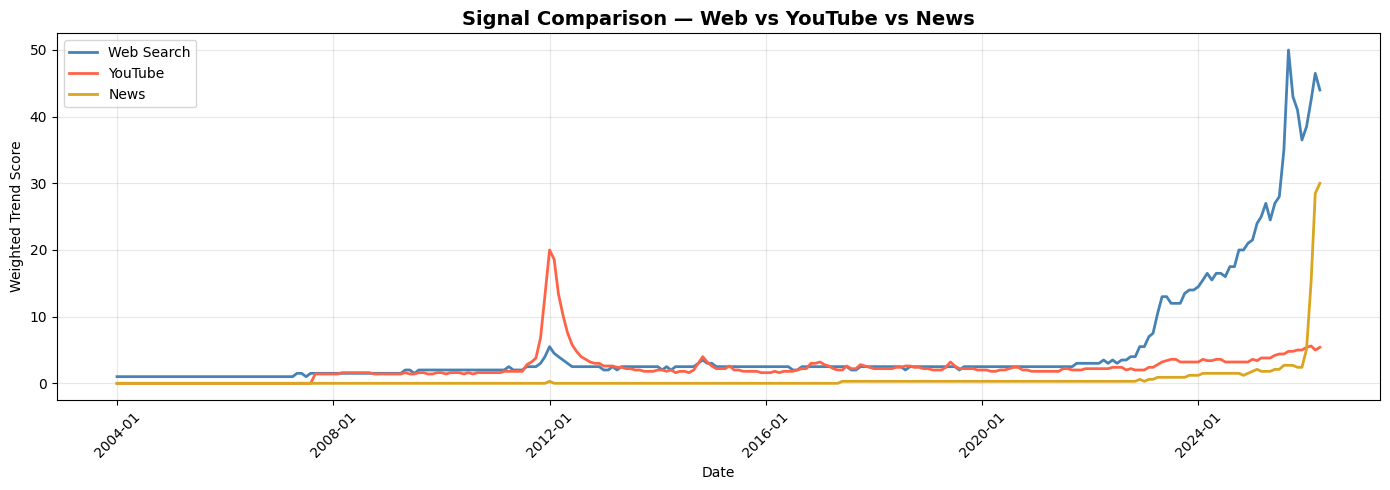

In [199]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

# -------------------------
# 1. All three signals
# -------------------------
def plot_signals(web_clean, youtube_clean, news_clean):
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(web_clean["ds"],     web_clean["y"],     color="steelblue",  linewidth=2, label="Web Search")
    ax.plot(youtube_clean["ds"], youtube_clean["y"], color="tomato",     linewidth=2, label="YouTube")
    ax.plot(news_clean["ds"],    news_clean["y"],    color="goldenrod",  linewidth=2, label="News")

    ax.set_title("Signal Comparison — Web vs YouTube vs News", fontsize=14, fontweight="bold")
    ax.set_ylabel("Weighted Trend Score")
    ax.set_xlabel("Date")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# -------------------------
# 2. Regime
# -------------------------
def plot_regime(analysis_df):
    regime_colors = {
        "Spike":             "#c8f7c5",
        "Building":          "#fef9c3",
        "Quiet":             "#f0f0f0",
        "Collapsing":        "#fdd",
        "Insufficient Data": "#ffffff"
    }

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(14, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )

    # Shade background by regime
    for i in range(len(analysis_df) - 1):
        regime = analysis_df["regime"].iloc[i]
        ax1.axvspan(
            analysis_df["ds"].iloc[i],
            analysis_df["ds"].iloc[i + 1],
            color=regime_colors.get(regime, "#ffffff"),
            alpha=0.5
        )

    ax1.plot(analysis_df["ds"], analysis_df["y"], color="#1a1a2e", linewidth=2, label="Trend Score")
    ax1.set_ylabel("Trend Score")
    ax1.set_title("Regime Classification", fontsize=14, fontweight="bold")
    ax1.grid(alpha=0.3)

    # Z-scores
    ax2.plot(analysis_df["ds"], analysis_df["velocity_short_zscore"], color="tomato",    linewidth=2, label="Short Z (14d)")
    ax2.plot(analysis_df["ds"], analysis_df["velocity_long_zscore"],  color="steelblue", linewidth=2, label="Long Z (60d)")
    ax2.axhline(y=2,    color="green", linestyle="--", alpha=0.6, linewidth=1, label="Spike threshold (z=2)")
    ax2.axhline(y=-1.5, color="red",   linestyle="--", alpha=0.6, linewidth=1, label="Collapse threshold (z=-1.5)")
    ax2.axhline(y=0,    color="gray",  linestyle="-",  alpha=0.2, linewidth=1)
    ax2.set_ylabel("Z-Score")
    ax2.set_xlabel("Date")
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

    # Regime legend
    patches = [
        mpatches.Patch(color="#c8f7c5", label="Spike — Act Now"),
        mpatches.Patch(color="#fef9c3", label="Building — Watch"),
        mpatches.Patch(color="#f0f0f0", label="Quiet — Wait"),
        mpatches.Patch(color="#fdd",    label="Collapsing — Hold"),
    ]
    ax1.legend(handles=patches, loc="upper left", fontsize=8)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# -------------------------
# 3. Prophet forecast
# -------------------------
def plot_forecast(analysis_df, forecast_df):
    fig, ax = plt.subplots(figsize=(14, 5))

    # Historical
    ax.plot(analysis_df["ds"], analysis_df["y"],
            color="steelblue", linewidth=2, label="Historical")

    # Forecast line
    ax.plot(forecast_df["ds"], forecast_df["yhat"],
            color="tomato", linewidth=2, linestyle="--", label="Forecast")

    # Confidence interval
    ax.fill_between(
        forecast_df["ds"],
        forecast_df["yhat_lower"],
        forecast_df["yhat_upper"],
        color="tomato", alpha=0.15, label="Confidence Interval"
    )

    # Mark where forecast starts
    cutoff = analysis_df["ds"].max()
    ax.axvline(x=cutoff, color="gray", linestyle="--", alpha=0.5, label="Forecast start")

    ax.set_title("Trend Forecast — Next 30 Days", fontsize=14, fontweight="bold")
    ax.set_ylabel("Trend Score")
    ax.set_xlabel("Date")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# -------------------------
# usage
# -------------------------
plot_signals(web_clean, youtube_clean, news_clean)


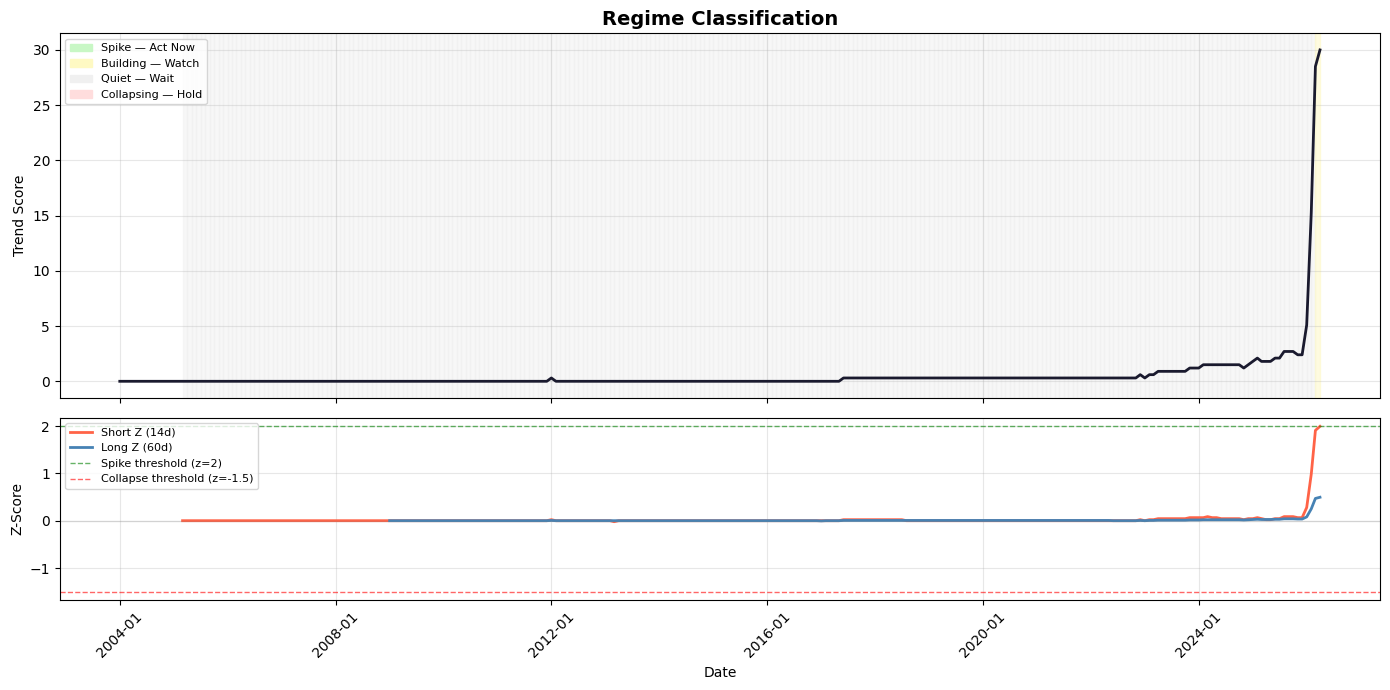

In [200]:
plot_regime(com)


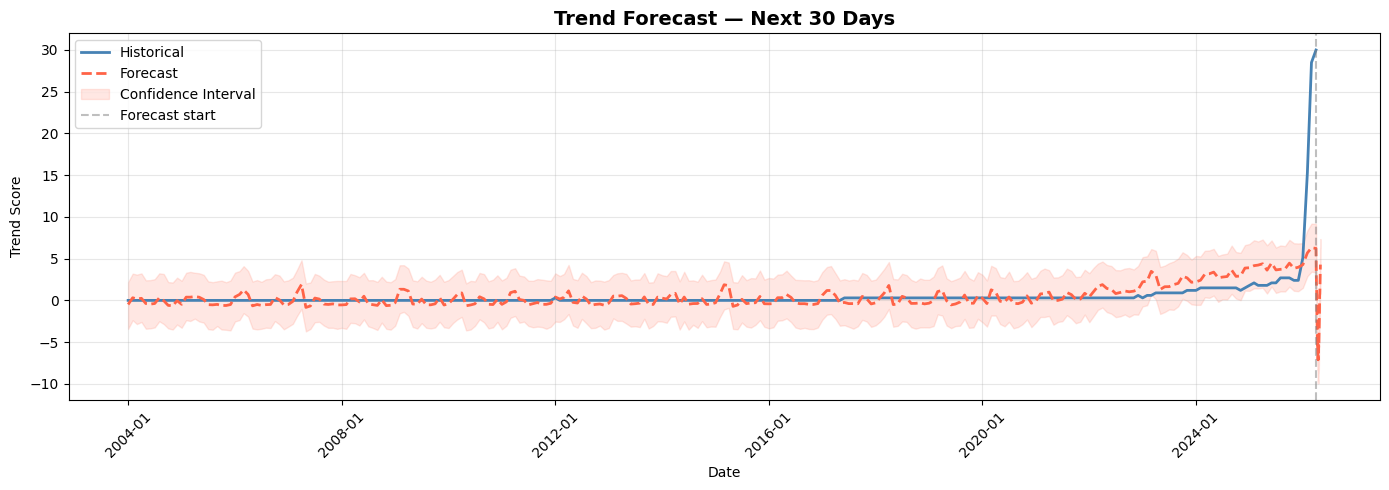

In [201]:
plot_forecast(com, forecast_df)